In [1]:
import pandas as pd
from matplotlib.pyplot import xticks

data=pd.read_csv("../data/vehicles_cleaned.csv")

In [2]:
import matplotlib.pyplot as plt


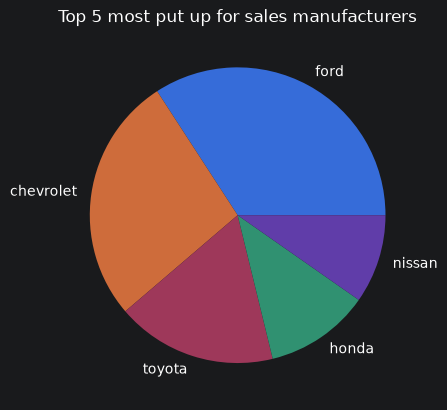

In [3]:
manufacturers={}
lng=data.shape[0]
for man in data.columns[data.columns.str.startswith("manufacturer")]:
    manufacturers[man]=data[man].sum()

manufacturers_new={}
for key,value in manufacturers.items():
    key_new=key.replace("manufacturer_","")
    manufacturers_new[key_new]=value

manufacturers_new={k: v for k, v in sorted(manufacturers_new.items(), key=lambda item: item[1],reverse=True)}
manufacturers_new

top5=list(manufacturers_new.items())[:5]
top5_key=[d[0]   for d in top5 ]
top5_val=[d[1]   for d in top5 ]
plt.title("Top 5 most put up for sales manufacturers")
plt.pie(top5_val,labels=top5_key)

#the pie chart shows that top 5 most put up for sales manufacturers are ford chevrolet,toyota, honda, nissan

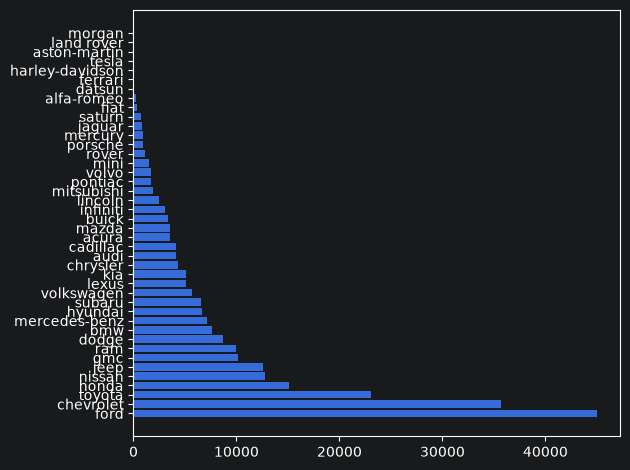

In [4]:
plt.barh(manufacturers_new.keys(),manufacturers_new.values())
plt.tight_layout()
plt.show()

#barplot shows the number of sales by each manufacturer, we know top 5 bestsellers from pie chart, but from this we can also conclude that weakest sales are among morgan, land rover, aston-martin, tesla. From this graph we can conclude that people in the USA are at most users of basic/ most popular manufacturers, while premium cars manufacturers are still unavailable for everyone

Text(0.5, 1.0, 'Most put up for sales types of vehicles')

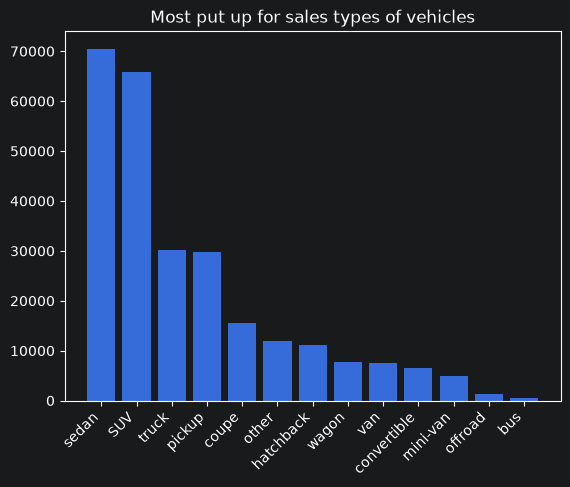

In [5]:
types={}
for type in data.columns[data.columns.str.startswith("type")]:
    types[type]=data[type].sum()

types_new={}
for key,value in types.items():
    key_new=key.replace("type_","")
    types_new[key_new]=value

types_new={k: v for k, v in sorted(types_new.items(), key=lambda item: item[1],reverse=True)}
plt.bar(types_new.keys(),types_new.values())
plt.xticks(rotation=45,ha='right')
plt.title("Most put up for sales types of vehicles")
#from the graph we can conclude that most common put up for sales type are sedan and SUV, which could mean that most users are looking for basic car for home or for their families. The least put up on sales is bus, what is understandable, because we can see less buses on roads that basic cars and basic user won't buy a bus for himself.

Text(0.5, 1.0, 'Most common type of fuel per vehicle')

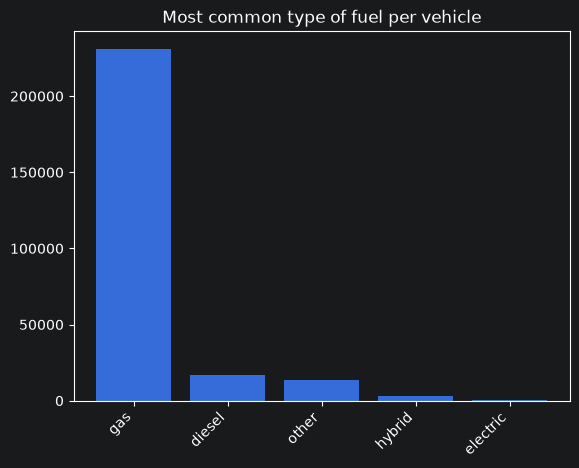

In [6]:
fuel={}
for fl in data.columns[data.columns.str.startswith("fuel")]:
    fuel[fl]=data[fl].sum()

fuel_new={}
for key,value in fuel.items():
    key_new=key.replace("fuel_","")
    fuel_new[key_new]=value

fuel_new={k: v for k, v in sorted(fuel_new.items(), key=lambda item: item[1],reverse=True)}
plt.bar(fuel_new.keys(),fuel_new.values())
plt.xticks(rotation=45,ha='right')
plt.title("Most common type of fuel per vehicle")
# Gasoline-powered vehicles are the most common in the dataset, while electric vehicles are the least represented.The low share of electric vehicles may be related to their lower market availability in 2021. However, the dataset alone does not allow us to determine the exact reasons for this distribution.

Text(0.5, 1.0, 'Top 10 states with higher sales')

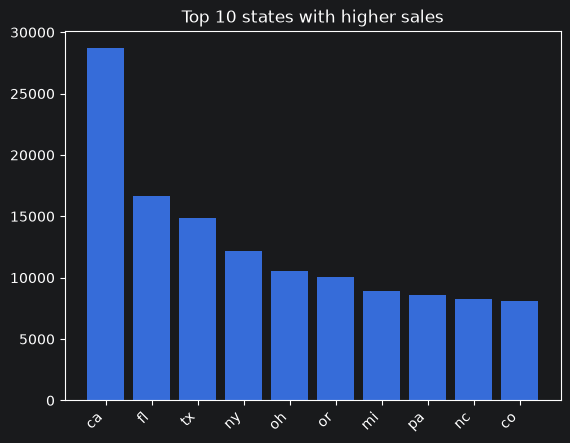

In [7]:
state={}
for st in data.columns[data.columns.str.startswith("state")]:
    state[st]=data[st].sum()

state_new={}
for key,value in state.items():
    key_new=key.replace("state_","")
    state_new[key_new]=value

state_new={k: v for k, v in sorted(state_new.items(), key=lambda item: item[1],reverse=True)}
top10=list(state_new.items())[:10]
top10_key=[d[0]   for d in top10 ]
top10_val=[d[1]   for d in top10 ]
plt.bar(top10_key,top10_val)
plt.xticks(rotation=45,ha='right')
plt.title("Top 10 states with higher sales")

#most popular states according to market are California, Florida, Texas,New York, Ohio, Orlando, Miami, Pennsylvania, Nort Carolina, Colorado

In [8]:
#correlation between odometer and price
cr = data["odometer"].corr(data["price"])
cr

# This is quite interesting because the correlation between odometer and price is very weak(0.000987). This suggests that there is no strong linear relationship between mileage and car price in this dataset.

np.float64(0.000987390143973671)

0.004269979993254061


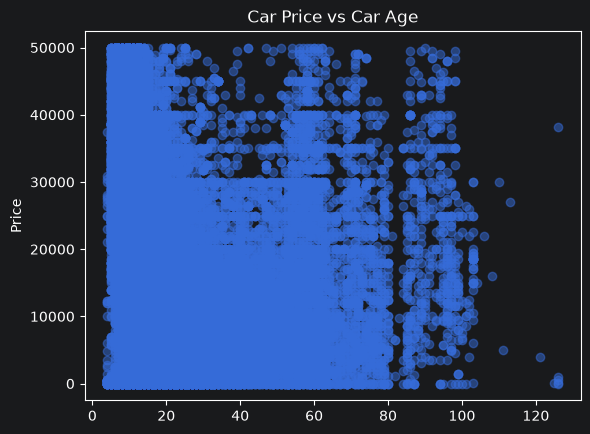

In [43]:
#plt.scatter(data["age"],data["price"],alpha=0.5)
#plt.xlabel("Age")
plt.ylabel("Price")
plt.title("Car Price vs Car Age")
#from this plot we can't conclude much because of the outliers we cant see trend


plot_data=data[data["price"]<50000][["age","price"]]
plot_data
plt.scatter(plot_data["age"],plot_data["price"],alpha=0.5)

#even after filtering records we can't see any trend

cr = data["age"].corr(data["price"])
print(cr)
#another proof of that is weak correlation(0.0043)


In [10]:
import seaborn as sns

Text(0.5, 1.0, 'Car Price Distribution by Fuel Type')

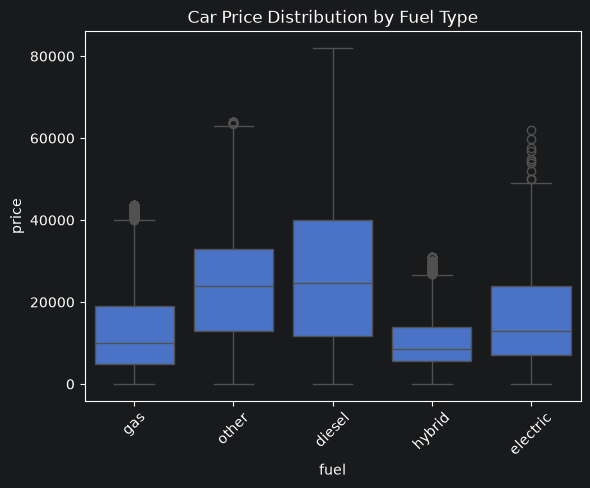

In [11]:
fuel_cols = data.columns[data.columns.str.startswith("fuel_")]
fuel_data = data[fuel_cols].idxmax(axis=1)
fuel_data = fuel_data.str.replace("fuel_", "")
plot_data = pd.DataFrame({"fuel": fuel_data,"price": data["price"]})
#sns.boxplot(data=plot_data, x="fuel", y="price")
#plt.xticks(rotation=45)
#plt.title("Car Price Distribution by Fuel Type")
#outliers enable us to analyze data correctly


Q1 = plot_data.groupby("fuel")["price"].transform("quantile", 0.25)
Q3 = plot_data.groupby("fuel")["price"].transform("quantile", 0.75)
IQR = Q3 - Q1
plot_data_clean = plot_data[(plot_data["price"] >= Q1 - 1.5 * IQR) &(plot_data["price"] <= Q3 + 1.5 * IQR)]

sns.boxplot(data=plot_data_clean, x="fuel", y="price")

plt.xticks(rotation=45)
plt.title("Car Price Distribution by Fuel Type")

#Now we can read data from graph.  The Biggest price range is in diesel fuel and median is also the biggest. The reverse situation is hybrid cars, there are represented by lowest median and lowest price range.

Text(0.5, 1.0, 'Car Price Distribution by Type')

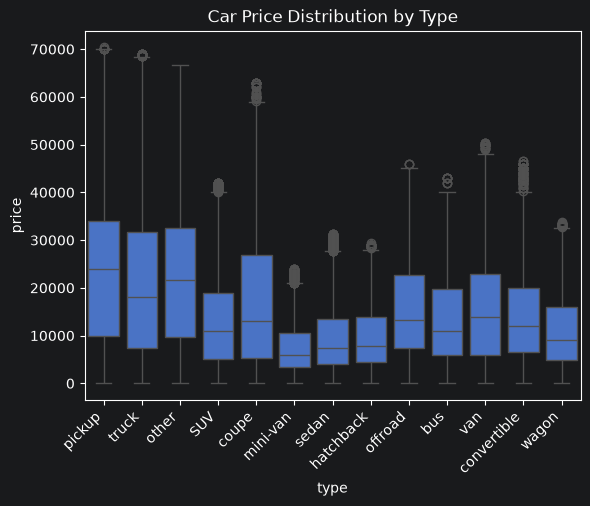

In [19]:
type_cols=data.columns[data.columns.str.startswith("type_")]
type_data=data[type_cols].idxmax(axis=1)
type_data = type_data.str.replace("type_", "")
plot_data=pd.DataFrame({"type":type_data,"price":data["price"]})

#sns.boxplot(data=plot_data, x="type", y="price")
#Due to outliers we can't make any conclusions based on this plot, we have to delete outliers

Q1=plot_data.groupby("type")["price"].transform("quantile", 0.25)
Q3=plot_data.groupby("type")["price"].transform("quantile", 0.75)
IQR = Q3 - Q1
plot_data_clean=plot_data[(plot_data["price"]>=Q1-1.5*IQR) & (plot_data["price"]<=Q3+1.5*IQR)]
sns.boxplot(data=plot_data_clean, x="type", y="price")
plt.xticks(ha='right',rotation=45)
plt.title("Car Price Distribution by Type")
#Graph shows us car price distribution by car type. On the graph we can see price range for each car(ex. biggest price range is in pickup). Boxplot also shows us the median for each car type(also pickup has largest median). Boxplot also shows outliers which we didn't delete during preprocessing.

In [21]:
cr=data["odometer"].corr(data["age"])
#Correlation between odometer and car's age is 0.14, it shows that we can weak(but it exist ) linear dependency between those 2 variables.

np.float64(0.14102877183748447)

Text(0.5, 1.0, 'Top 10 highest median car prices')

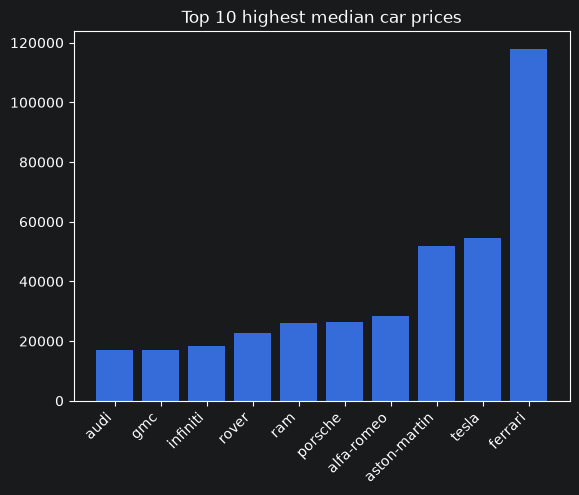

In [46]:
man_cols=data.columns[data.columns.str.startswith("manufacturer_")]
data_man=data[man_cols].idxmax(axis=1)
data_man=data_man.str.replace("manufacturer_", "")
man_price=pd.DataFrame({"manufacturer":data_man,"price":data["price"]})
man_price=man_price.groupby(by="manufacturer")["price"].median().sort_values().tail(10)


plt.bar(man_price.index,height=man_price.values)
plt.xticks(ha='right',rotation=45)
plt.title("Top 10 highest median car prices")
# The plot shows the 10 manufacturers with the highest median car prices. Ferrari has by far the highest median price. Interestingly, Tesla, which ranks second, has a median price that is more than twice as low as Ferrari's.

Text(0.5, 1.0, 'Top 10 lowest median car prices')

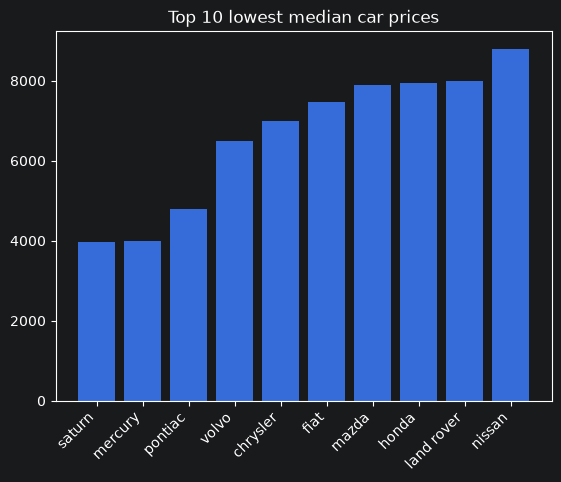

In [48]:
man_price=pd.DataFrame({"manufacturer":data_man,"price":data["price"]})
man_price=man_price.groupby(by="manufacturer")["price"].median().sort_values().head(10)
plt.bar(man_price.index,height=man_price.values)
plt.xticks(ha='right',rotation=45)
plt.title("Top 10 lowest median car prices")
# The plot shows the 10 manufacturers with the lowest median car prices. Saturn has by far the lowest median price. Price range between those 10 medians isn't huge(it's about 4k dollars) compared to price range between 10 most expensive cars.